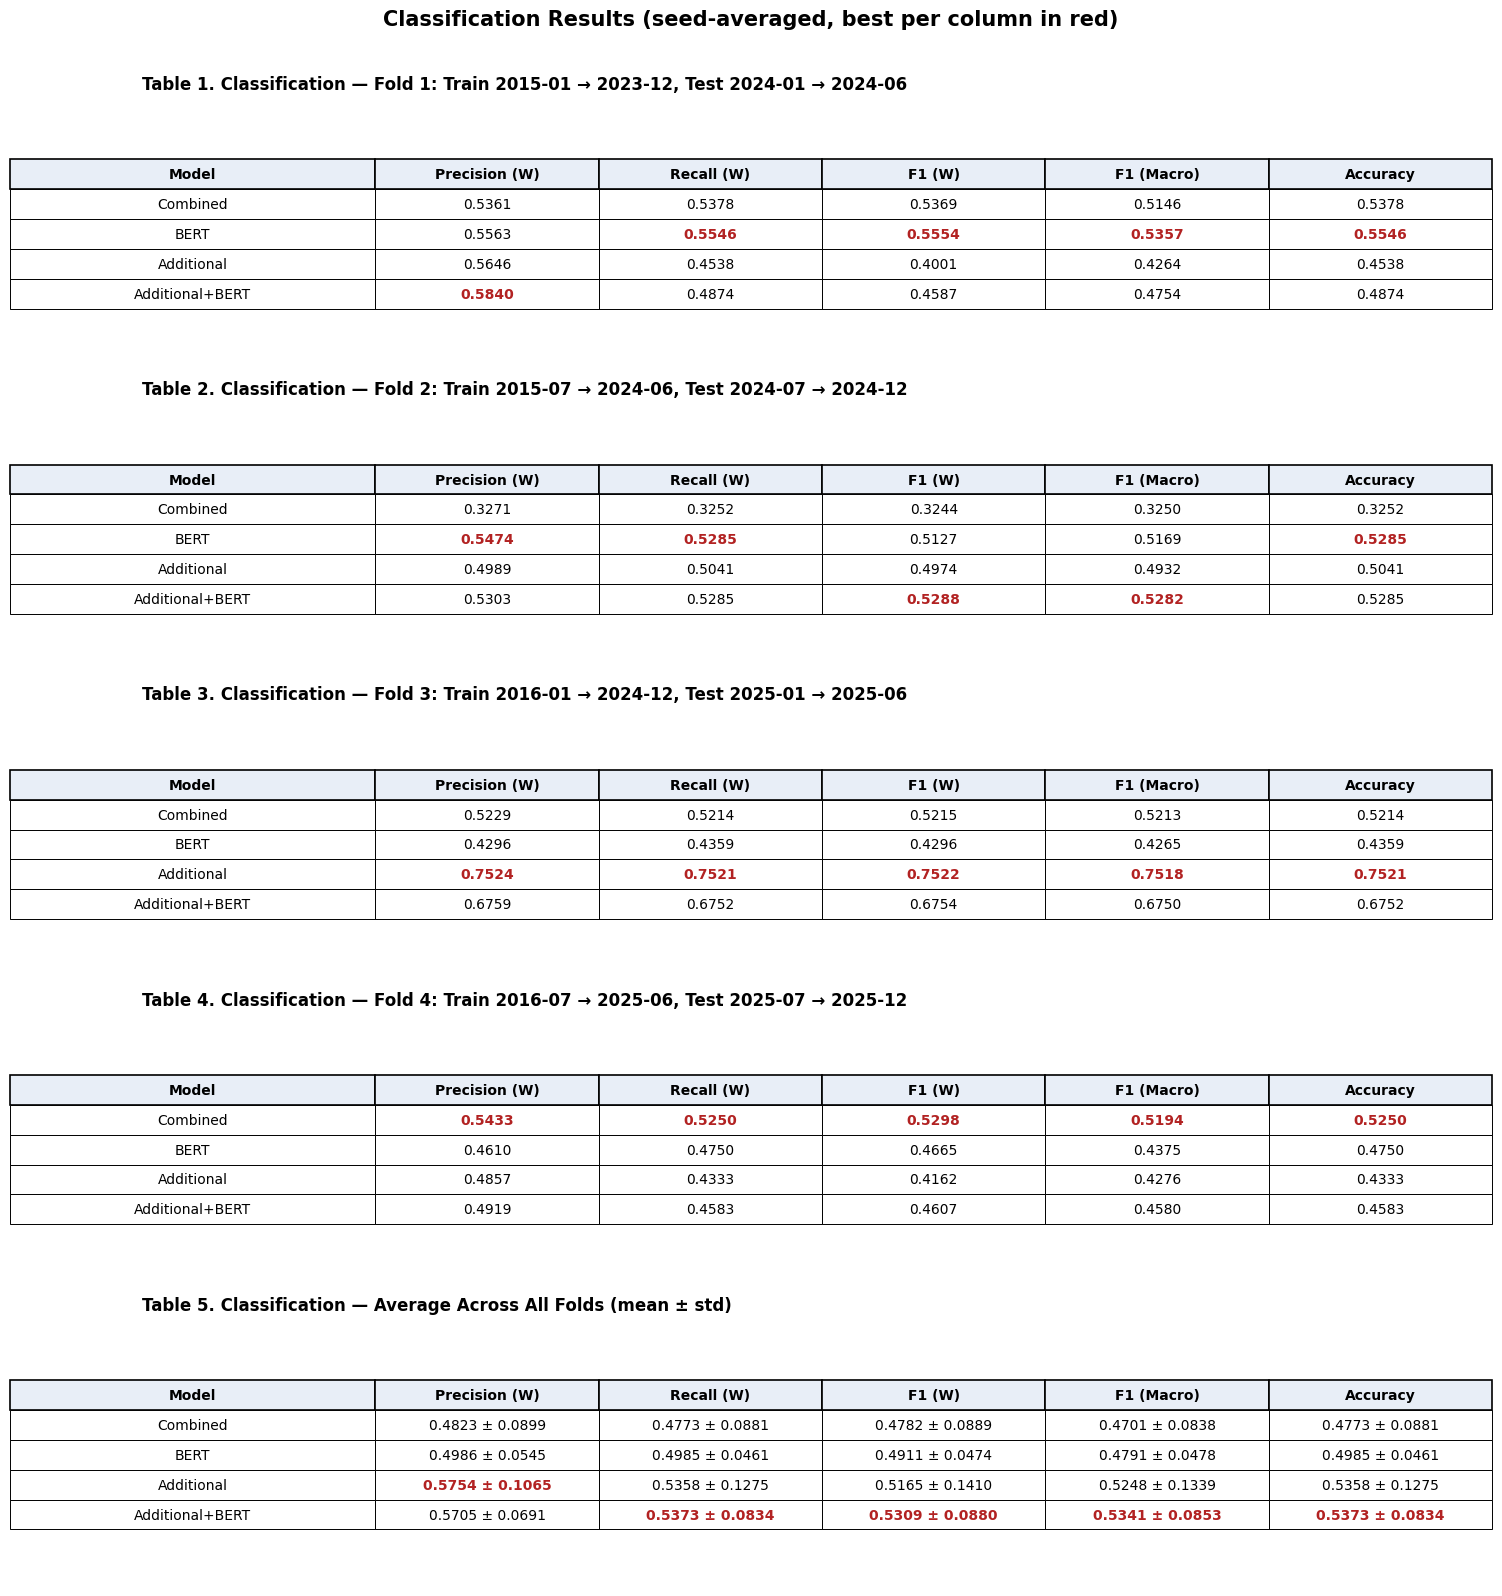

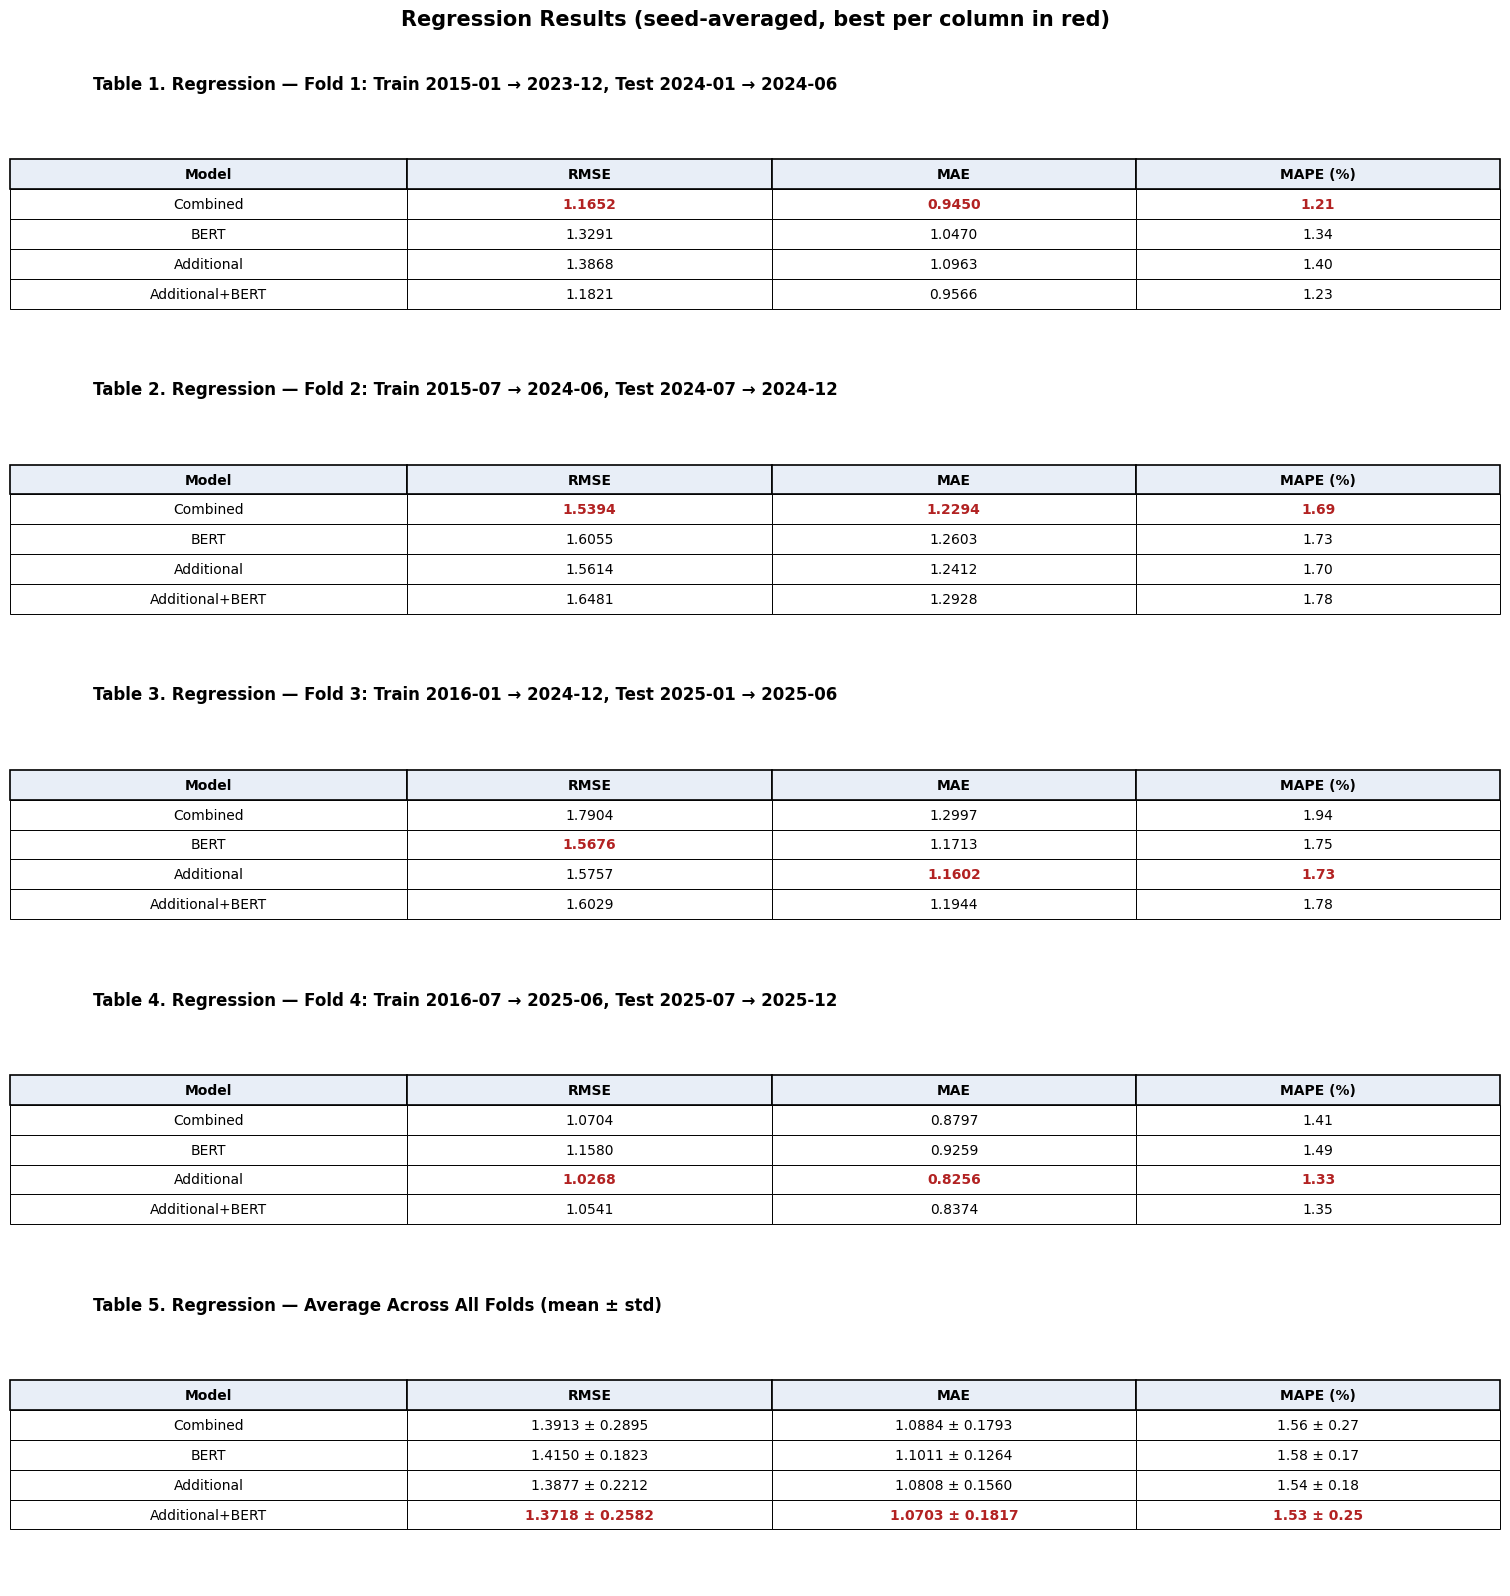

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =========================
# 1. Model names & latest numbers (seed-averaged)
# =========================

models = ['Combined', 'BERT', 'Additional', 'Additional+BERT']

# ----- Classification -----
cls_fold1 = pd.DataFrame({'Model': models,
    'Precision (W)': [0.5361, 0.5563, 0.5646, 0.5840],
    'Recall (W)':    [0.5378, 0.5546, 0.4538, 0.4874],
    'F1 (W)':        [0.5369, 0.5554, 0.4001, 0.4587],
    'F1 (Macro)':    [0.5146, 0.5357, 0.4264, 0.4754],
    'Accuracy':      [0.5378, 0.5546, 0.4538, 0.4874]})
cls_fold2 = pd.DataFrame({'Model': models,
    'Precision (W)': [0.3271, 0.5474, 0.4989, 0.5303],
    'Recall (W)':    [0.3252, 0.5285, 0.5041, 0.5285],
    'F1 (W)':        [0.3244, 0.5127, 0.4974, 0.5288],
    'F1 (Macro)':    [0.3250, 0.5169, 0.4932, 0.5282],
    'Accuracy':      [0.3252, 0.5285, 0.5041, 0.5285]})
cls_fold3 = pd.DataFrame({'Model': models,
    'Precision (W)': [0.5229, 0.4296, 0.7524, 0.6759],
    'Recall (W)':    [0.5214, 0.4359, 0.7521, 0.6752],
    'F1 (W)':        [0.5215, 0.4296, 0.7522, 0.6754],
    'F1 (Macro)':    [0.5213, 0.4265, 0.7518, 0.6750],
    'Accuracy':      [0.5214, 0.4359, 0.7521, 0.6752]})
cls_fold4 = pd.DataFrame({'Model': models,
    'Precision (W)': [0.5433, 0.4610, 0.4857, 0.4919],
    'Recall (W)':    [0.5250, 0.4750, 0.4333, 0.4583],
    'F1 (W)':        [0.5298, 0.4665, 0.4162, 0.4607],
    'F1 (Macro)':    [0.5194, 0.4375, 0.4276, 0.4580],
    'Accuracy':      [0.5250, 0.4750, 0.4333, 0.4583]})
cls_avg = pd.DataFrame({'Model': models,
    'Precision (W)': [0.4823, 0.4986, 0.5754, 0.5705],
    'Recall (W)':    [0.4773, 0.4985, 0.5358, 0.5373],
    'F1 (W)':        [0.4782, 0.4911, 0.5165, 0.5309],
    'F1 (Macro)':    [0.4701, 0.4791, 0.5248, 0.5341],
    'Accuracy':      [0.4773, 0.4985, 0.5358, 0.5373]})
cls_avg_std = pd.DataFrame({'Model': models,
    'Precision (W)': [0.0899, 0.0545, 0.1065, 0.0691],
    'Recall (W)':    [0.0881, 0.0461, 0.1275, 0.0834],
    'F1 (W)':        [0.0889, 0.0474, 0.1410, 0.0880],
    'F1 (Macro)':    [0.0838, 0.0478, 0.1339, 0.0853],
    'Accuracy':      [0.0881, 0.0461, 0.1275, 0.0834]})

# ----- Regression -----
reg_fold1 = pd.DataFrame({'Model': models,
    'RMSE':     [1.1652, 1.3291, 1.3868, 1.1821],
    'MAE':      [0.9450, 1.0470, 1.0963, 0.9566],
    'MAPE (%)': [1.21,   1.34,   1.40,   1.23]})
reg_fold2 = pd.DataFrame({'Model': models,
    'RMSE':     [1.5394, 1.6055, 1.5614, 1.6481],
    'MAE':      [1.2294, 1.2603, 1.2412, 1.2928],
    'MAPE (%)': [1.69,   1.73,   1.70,   1.78]})
reg_fold3 = pd.DataFrame({'Model': models,
    'RMSE':     [1.7904, 1.5676, 1.5757, 1.6029],
    'MAE':      [1.2997, 1.1713, 1.1602, 1.1944],
    'MAPE (%)': [1.94,   1.75,   1.73,   1.78]})
reg_fold4 = pd.DataFrame({'Model': models,
    'RMSE':     [1.0704, 1.1580, 1.0268, 1.0541],
    'MAE':      [0.8797, 0.9259, 0.8256, 0.8374],
    'MAPE (%)': [1.41,   1.49,   1.33,   1.35]})
reg_avg = pd.DataFrame({'Model': models,
    'RMSE':     [1.3913, 1.4150, 1.3877, 1.3718],
    'MAE':      [1.0884, 1.1011, 1.0808, 1.0703],
    'MAPE (%)': [1.56,   1.58,   1.54,   1.53]})
reg_avg_std = pd.DataFrame({'Model': models,
    'RMSE':     [0.2895, 0.1823, 0.2212, 0.2582],
    'MAE':      [0.1793, 0.1264, 0.1560, 0.1817],
    'MAPE (%)': [0.27,   0.17,   0.18,   0.25]})

fold_titles = [
    'Fold 1: Train 2015-01 → 2023-12, Test 2024-01 → 2024-06',
    'Fold 2: Train 2015-07 → 2024-06, Test 2024-07 → 2024-12',
    'Fold 3: Train 2016-01 → 2024-12, Test 2025-01 → 2025-06',
    'Fold 4: Train 2016-07 → 2025-06, Test 2025-07 → 2025-12',
]

# =========================
# 2. Draw one table onto a given Axes
# =========================

def draw_table(ax, df, title, maximize_cols=None, minimize_cols=None,
               std_df=None, fmt_map=None):
    maximize_cols = maximize_cols or []
    minimize_cols = minimize_cols or []
    fmt_map = fmt_map or {}

    def fmt(col, v): return fmt_map.get(col, '{:.4f}').format(v)

    display_df = df.copy()
    for col in display_df.columns:
        if col == 'Model': continue
        if std_df is not None:
            display_df[col] = [f'{fmt(col, v)} ± {fmt(col, s)}'
                               for v, s in zip(df[col], std_df[col])]
        else:
            display_df[col] = df[col].map(lambda x: fmt(col, x))

    best_cells = set()
    for col in maximize_cols:
        best_cells.add((df[col].idxmax() + 1, list(df.columns).index(col)))
    for col in minimize_cols:
        best_cells.add((df[col].idxmin() + 1, list(df.columns).index(col)))

    ax.axis('off')
    table = ax.table(cellText=display_df.values, colLabels=display_df.columns,
                     cellLoc='center', loc='center')
    table.auto_set_font_size(False); table.set_fontsize(10); table.scale(1.1, 1.45)

    for col_idx in range(len(display_df.columns)):
        cell = table[(0, col_idx)]
        cell.set_text_props(weight='bold'); cell.set_facecolor('#E8EEF7')
        cell.set_linewidth(1.2)
    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor('black')
        if row > 0: cell.set_linewidth(0.7)
    for row, col in best_cells:
        table[(row, col)].set_text_props(weight='bold', color='#B22222')
    for row in range(len(display_df) + 1):
        table[(row, 0)].set_width(0.30)

    ax.set_title(title, fontsize=12, weight='bold', pad=10, loc='left')

# =========================
# 3. Combined figure for each task (5 stacked tables: 4 folds + average)
# =========================

def plot_task(task_name, folds_dfs, avg_df, avg_std_df,
              metric_cols, direction, fmt_map, filename, header):
    fig, axes = plt.subplots(5, 1, figsize=(15, 16))
    fig.suptitle(header, fontsize=15, weight='bold', y=0.995)
    for i, (ax, df) in enumerate(zip(axes[:4], folds_dfs)):
        draw_table(ax, df,
                   title=f'Table {i+1}. {task_name} — {fold_titles[i]}',
                   maximize_cols=metric_cols if direction == 'max' else None,
                   minimize_cols=metric_cols if direction == 'min' else None,
                   fmt_map=fmt_map)
    draw_table(axes[4], avg_df,
               title=f'Table 5. {task_name} — Average Across All Folds (mean ± std)',
               maximize_cols=metric_cols if direction == 'max' else None,
               minimize_cols=metric_cols if direction == 'min' else None,
               std_df=avg_std_df, fmt_map=fmt_map)
    plt.tight_layout(rect=[0, 0, 1, 0.985])
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

# Classification: higher = better
plot_task(
    'Classification',
    [cls_fold1, cls_fold2, cls_fold3, cls_fold4],
    cls_avg, cls_avg_std,
    metric_cols=['Precision (W)', 'Recall (W)', 'F1 (W)', 'F1 (Macro)', 'Accuracy'],
    direction='max',
    fmt_map={},
    filename='classification_results_tables.png',
    header='Classification Results (seed-averaged, best per column in red)',
)

# Regression: lower = better
plot_task(
    'Regression',
    [reg_fold1, reg_fold2, reg_fold3, reg_fold4],
    reg_avg, reg_avg_std,
    metric_cols=['RMSE', 'MAE', 'MAPE (%)'],
    direction='min',
    fmt_map={'RMSE': '{:.4f}', 'MAE': '{:.4f}', 'MAPE (%)': '{:.2f}'},
    filename='regression_results_tables.png',
    header='Regression Results (seed-averaged, best per column in red)',
)
